In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
def plot_dataset(dataset, feature_names, colorsort, nsorted, sort_labels, 
                 sort_title="categories", cluster_centres=None):

    fig, axs = plt.subplots(
        len(feature_names), len(feature_names), figsize=(50,20))

    axs = axs.T
    for x in range(len(feature_names)):
        x_label = feature_names[x]
        axs[x,-1].set_xlabel(x_label)
        for y in range(len(feature_names)):
            if x<y:
                y_label = feature_names[y]
                axs[x,y].scatter(dataset[x_label][:], dataset[y_label][:], c=dataset[colorsort], alpha=0.5)
                if x_label in dataset and y_label in dataset and cluster_centres is not None:
                    axs[x,y].scatter(cluster_centres[x_label], cluster_centres[y_label], marker="^", c=range(0, nsorted), s=300)
                axs[0,y].set_ylabel(y_label)
            elif x==y:
                plotData = [dataset.loc[(dataset[colorsort]==c)][x_label] for c in range(0, nsorted)]
                axs[x,y].hist(plotData, stacked=True, label=sort_labels)
                axs[x,y].set_ylabel(sort_title)
                axs[x,y].legend()
            else:
                axs[x,y].set_visible(False)
    plt.show()

In [3]:
def find_cluster_centres(dataset, kmeans_model):
    cluster_centres = {}
    for a,b in zip(list(dataset), kmeans_model.cluster_centers_.T):
        cluster_centres[a] = b
    newdataset = dataset.copy()
    newdataset["cluster"] = kmeans_model.predict(dataset)
    
    return newdataset, cluster_centres

In [4]:
def assess_clustering(dataset, clustercol, targetcol, nclusters, ntargets, target_names, targetAxTitle):
    fig, ax = plt.subplots(2,1, figsize=(5,10))

    hist, xbins, ybins, im = ax[0].hist2d(dataset[clustercol], dataset[targetcol], bins=(ntargets,nclusters))
    ax[0].set_yticks(np.arange((ntargets-1)/(2*ntargets), ntargets-1, (ntargets-1)/ntargets), labels=target_names)
    ax[0].set_xticks(np.arange((nclusters-1)/(2*nclusters), nclusters-1, (nclusters-1)/nclusters), labels=np.arange(0, nclusters, 1))

    ax[0].set_xlabel("cluster")
    ax[0].set_ylabel(targetAxTitle)

    fig.colorbar(im)
    gini_impurity = np.zeros(nclusters)
    for i in range(len(xbins)-1):
        n_in_clust = sum(hist[i])
        gini = 1.001
        for j in range(len(ybins)-1):
            gini -= (hist[i,j]/n_in_clust)**2
            ax[0].text(xbins[j]+0.5,ybins[i]+0.5, "%0.f" %hist.T[i,j], 
                color="w", ha="center", va="center", fontweight="bold")
        gini_impurity[i] = gini
        

    ax[1].bar(np.arange(0, nclusters, 1), gini_impurity, width=0.8, align="center", color=gini_impurity)
    ax[1].set_xlabel("cluster")
    ax[1].set_xticks(np.arange(0, nclusters, 1), labels=np.arange(0, nclusters, 1))
    ax[1].set_ylabel("gini impurity")
    plt.show()

In [5]:
iris_dataset = load_iris(as_frame=True)

iris_data = iris_dataset["data"]
class_names = iris_dataset["target_names"]
feature_names = iris_dataset["feature_names"]

In [14]:
#1) Define the model
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto", algorithm="elkan")

#2)Train the model
kmeans.fit(iris_data)

KMeans(algorithm='elkan', n_clusters=3, random_state=0)

In [15]:
#3) Populate the data with target (species) and assigned clustering from the model
sorted_data, cluster_centres = find_cluster_centres(iris_data, kmeans)
sorted_data["target"] = iris_dataset["target"]

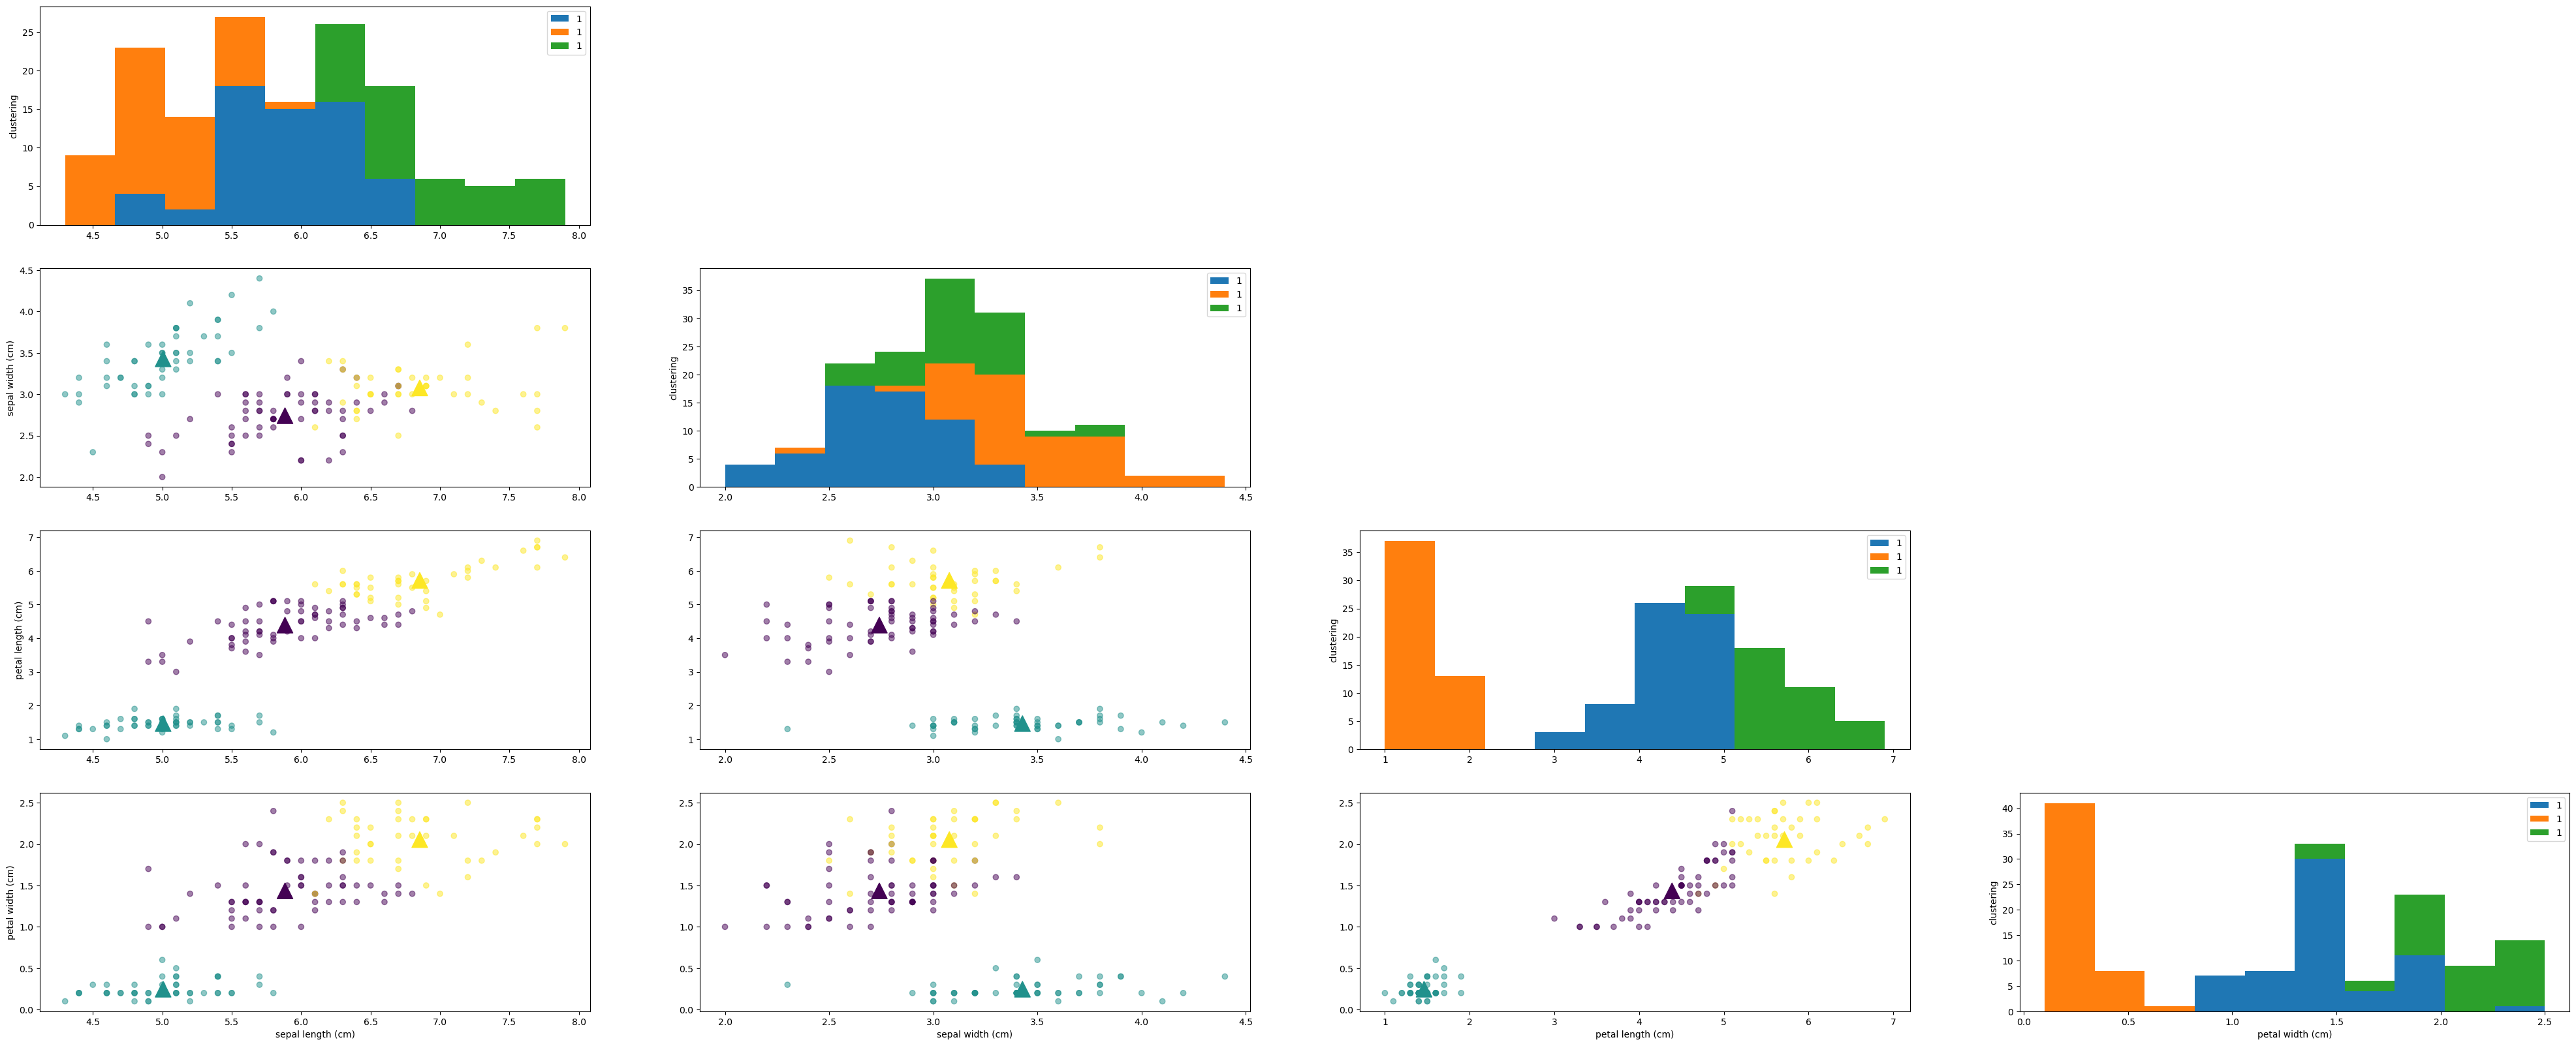

In [16]:
plot_dataset(sorted_data, feature_names, "cluster", 3, sorted_data["cluster"], sort_title="clustering", cluster_centres=cluster_centres)

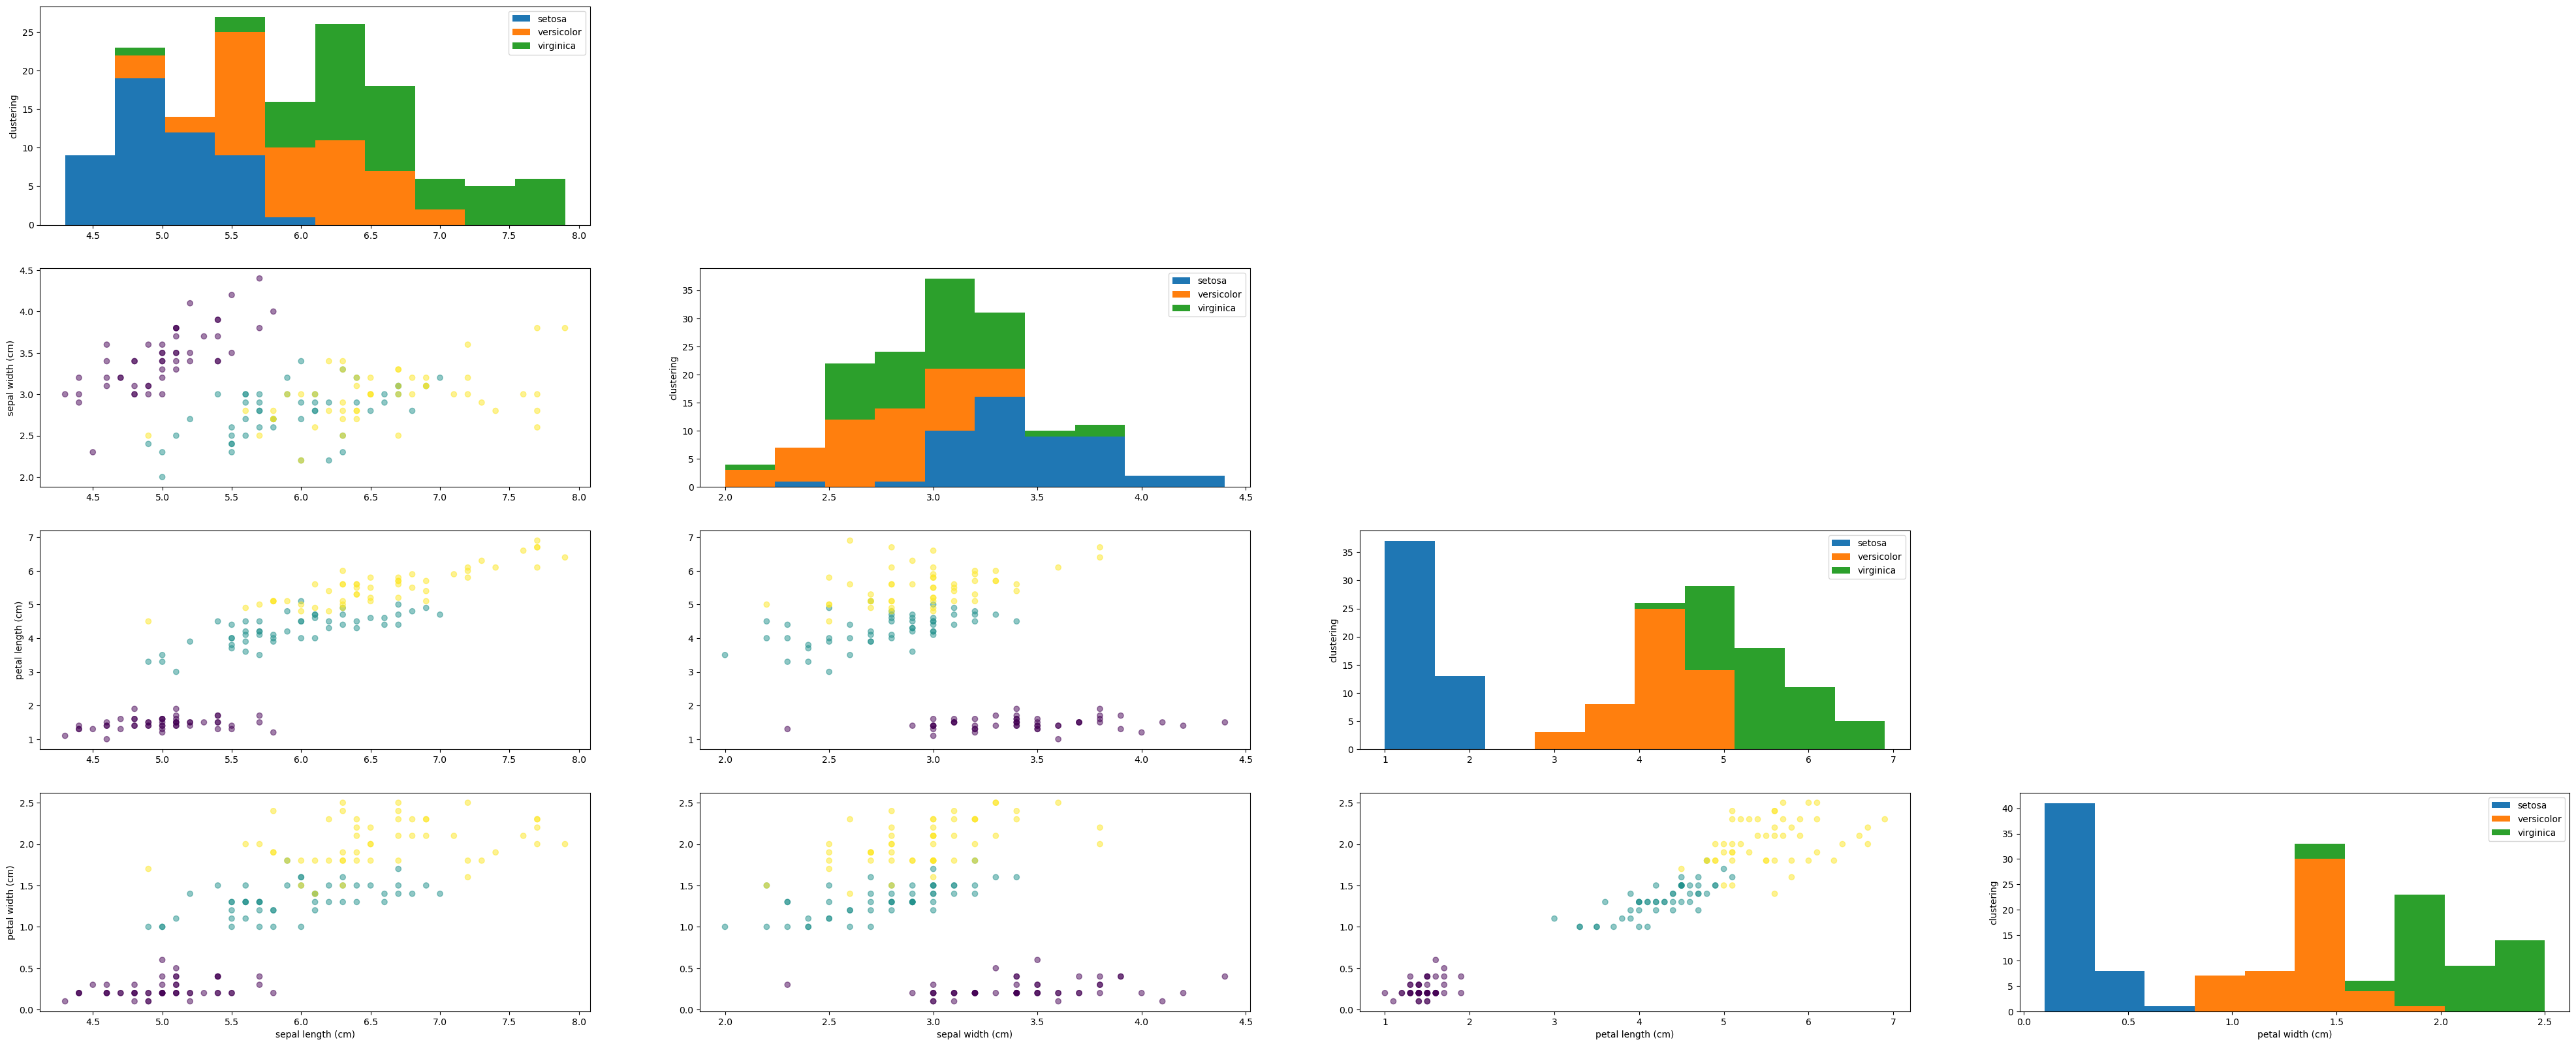

In [17]:
plot_dataset(sorted_data, feature_names, "target", 3, class_names, sort_title="clustering")

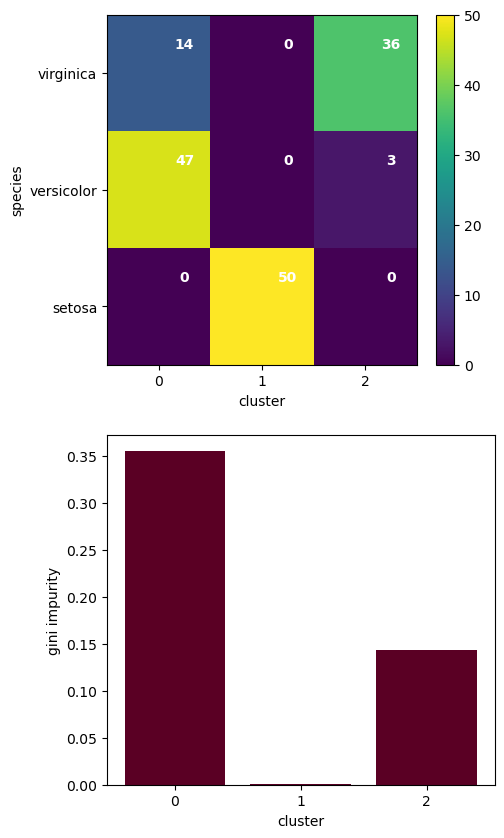

In [18]:
assess_clustering(sorted_data, "cluster", "target", 3, 3, class_names, "species")

In [19]:
#Now let's repeat, but instead doing the clustering on only a training sample and seeing how well it performs on
#unseen data

X_train, X_test, Y_train, Y_test = train_test_split(iris_data, iris_dataset["target"])
#1) Define the model
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")

#2)Train the model
kmeans.fit(X_train)

#3) Populate the data with target (species) and assigned clustering from the model
sorted_X_train, cluster_centres = find_cluster_centres(X_train, kmeans)
sorted_X_test, _ = find_cluster_centres(X_test, kmeans)
sorted_X_train["target"] = Y_train
sorted_X_test["target"] = Y_test

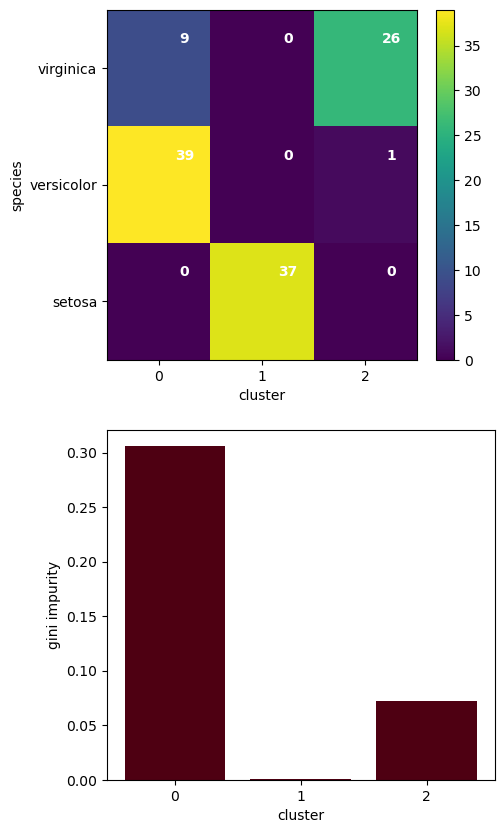

In [20]:
assess_clustering(sorted_X_train, "cluster", "target", 3, 3, class_names, "species")

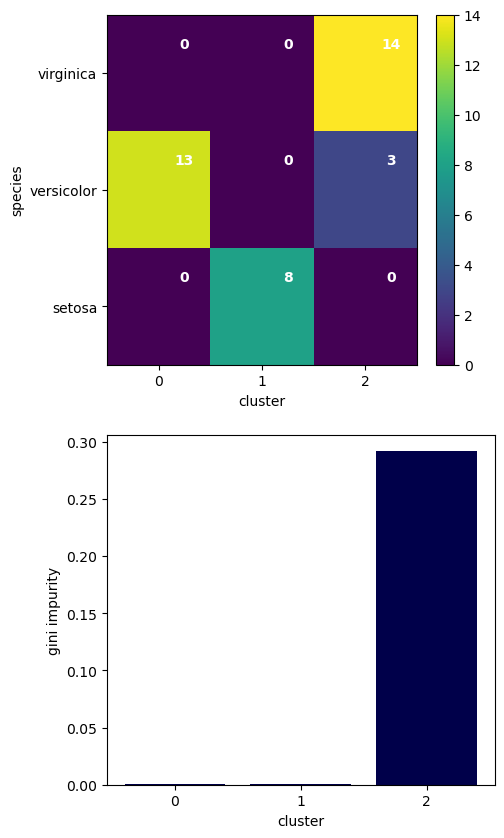

In [13]:
assess_clustering(sorted_X_test, "cluster", "target", 3, 3, class_names, "species")

In [25]:
clusters = kmeans.transform(X_train)
RF_classifier = RandomForestClassifier()

In [32]:
X_train, X_test, Y_train, Y_test= train_test_split(clusters, Y_train)

In [34]:
RF_classifier.fit(X_train, Y_train)

RandomForestClassifier()

In [35]:
RF_classifier.score(X_test, Y_test)

0.9642857142857143